<h1 style="color:#ffffff; background-color:#3D3456; text-align:center; font-weight:bold; padding:16px 10px; border-radius:8px; margin-bottom:6px;">Day 3 — RNNs &amp; LSTMs for Sequential Data</h1>
<h3 style="color:#6B5B95; text-align:center; font-weight:bold; margin-top:0;">Order-Aware Models, Hidden State, Vanishing Gradients, LSTM/GRU &amp; Mentor Review</h3>



<a id="toc"></a>
<h2 style="color:#F2C57C; background-color:#6B5B95; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">Table of Contents</h2>

<div style="border:1px solid #ccc; padding:15px 25px; border-radius:6px;">
<ul style="font-weight:bold; line-height:1.9; color:#1F2937;">
<li><a href="#section0">0. Setup — Imports & Reproducibility</a></li>
<li><a href="#section1">1. Day 3 Roadmap & Project Context</a></li>
<li><a href="#section2">2. Why Order Matters in Sequential Data</a></li>
<li><a href="#section3">3. RNNs — Hidden State as Memory</a></li>
<li><a href="#section4">4. The Vanishing-Gradient Problem</a></li>
<li><a href="#section5">5. LSTMs & GRUs — Gated Memory</a></li>
<li><a href="#section6">6. Embeddings for Text</a></li>
<li><a href="#section7">7. Hands-On Dataset — IMDb Sentiment</a></li>
<li><a href="#section8">8. Model A — Non-Sequential Baseline</a></li>
<li><a href="#section9">9. Model B — Simple RNN</a></li>
<li><a href="#section10">10. Model C — LSTM</a></li>
<li><a href="#section11">11. Optional GRU Experiment</a></li>
<li><a href="#section12">12. Model Comparison & Test Evaluation</a></li>
<li><a href="#section13">13. Order-Awareness Experiment</a></li>
<li><a href="#section14">14. What I Learned Today</a></li>
</ul>
</div>


<a id="section0"></a>
<h2 style="color:#F2C57C; background-color:#6B5B95; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">0. Setup — Imports, Reproducibility &amp; Runtime</h2>
<div style="border-left:5px solid #4AA883; background-color:#DFF3EA; padding:10px 15px; margin:10px 0; border-radius:4px; color:#285943;">
<b>Dataset path:</b> This notebook uses a local folder named <code>dataset</code> beside <code>Day3.ipynb</code>.
The IMDb dataset is stored as <code>dataset/imdb.npz</code>. If the file is missing on the first run,
Keras downloads it once and the notebook saves a local copy there for future runs.
</div>


In [ ]:
# Core imports
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available      :", bool(tf.config.list_physical_devices("GPU")))
print("GPU devices        :", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.21.0
GPU available      : False
GPU devices        : []



<div style="border-left:5px solid #6B5B95; background-color:#F3F1F7; padding:10px 15px; margin:10px 0; border-radius:4px; color:#332D40;">
<b>Reproducibility note:</b> A fixed seed makes model comparisons more meaningful. Exact neural-network results can
still vary slightly across hardware and TensorFlow versions, so focus on the overall pattern rather than expecting
identical decimals on every machine.
</div>



<a id="section1"></a>
<h2 style="color:#F2C57C; background-color:#6B5B95; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">1. Day 3 Roadmap &amp; Project Context</h2>

Today has two connected goals:

<ol style="line-height:1.8;">
<li>Understand and implement <b>sequence modeling</b> with RNNs and LSTMs.</li>
<li>Prepare the current work for the <b>mid-sprint Mentor Code &amp; Notebook Review</b>.</li>
</ol>

<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;"><table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#6B5B95; color:#F2C57C;"><th style="padding:8px; text-align:left;">Day 3 Requirement</th><th style="padding:8px; text-align:left;">How This Notebook Covers It</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Why order matters</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Concept example + order-reversal experiment</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">RNN hidden state</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Explanation + SimpleRNN model</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Vanishing gradients</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Concept explanation + visual intuition</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">LSTM / GRU gated memory</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">LSTM model + optional GRU experiment</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Embeddings</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Embedding layer for IMDb text</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Compare sequential models</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Baseline vs SimpleRNN vs LSTM</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Mentor review</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">PR checklist + review notes template</td></tr>
</table></div>



<div style="border-left:5px solid #E29A3B; background-color:#FFF5E6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7A4C16;">
<b>Important distinction:</b> Day 3 still studies RNNs/LSTMs using sequential text data.
The <code>dataset</code> folder for this notebook therefore stores IMDb sentiment sequences, while the image-based
Benign/Malignant dataset from Day 2 remains appropriate for CNN/Transfer Learning.
</div>



<a id="section2"></a>
<h2 style="color:#F2C57C; background-color:#6B5B95; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">2. Why Order Matters in Sequential Data</h2>

<h3 style="color:#F2C57C; font-weight:bold; background-color:#3D3456; display:inline-block; padding:4px 10px; border-radius:6px;">2.1 Sequential data</h3>

A sequence is data in which the <b>position and order of elements carry information</b>. Common examples are:

<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;"><table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#6B5B95; color:#F2C57C;"><th style="padding:8px; text-align:left;">Data Type</th><th style="padding:8px; text-align:left;">Sequence Element</th><th style="padding:8px; text-align:left;">Why Order Matters</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Text</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Words / tokens</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Word order changes meaning and grammar</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Time series</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Measurements over time</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Earlier values affect interpretation of later values</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Audio</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Signal frames</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Sound unfolds over time</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Sensor data</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Recorded readings</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Patterns depend on temporal progression</td></tr>
</table></div>

<div style="border-left:5px solid #D76B82; background-color:#FDECEF; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7A3344;">
<b>Key idea:</b> A bag-of-words style model can know <i>which</i> words are present but may lose information about
<i>where</i> they appeared. An RNN/LSTM processes tokens in sequence, which gives it a mechanism for remembering context.
</div>


In [2]:
# A tiny order-awareness example
sentence_a = ["the", "movie", "was", "not", "good"]
sentence_b = ["good", "the", "movie", "was", "not"]

print("Sentence A:", " ".join(sentence_a))
print("Sentence B:", " ".join(sentence_b))
print("\nSame vocabulary set? ", set(sentence_a) == set(sentence_b))
print("Same sequence?       ", sentence_a == sentence_b)


Sentence A: the movie was not good
Sentence B: good the movie was not

Same vocabulary set?  True
Same sequence?        False



<a id="section3"></a>
<h2 style="color:#F2C57C; background-color:#6B5B95; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">3. RNNs — Hidden State as Memory</h2>

A <b>Recurrent Neural Network (RNN)</b> processes one sequence element at a time. At each time step it combines:

<ul style="line-height:1.8;">
<li>the current input <b>x<sub>t</sub></b>, and</li>
<li>the previous hidden state <b>h<sub>t-1</sub></b>.</li>
</ul>

The result is a new hidden state <b>h<sub>t</sub></b>, which is passed to the next time step.

<div style="border-left:5px solid #6B5B95; background-color:#F3F1F7; padding:10px 15px; margin:10px 0; border-radius:4px; color:#332D40;">
<b>Intuition:</b> The hidden state is a compact working memory. When the model reaches a later word,
it can use information collected from earlier words instead of treating every token independently.
</div>



<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;"><table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#6B5B95; color:#F2C57C;"><th style="padding:8px; text-align:left;">Component</th><th style="padding:8px; text-align:left;">Role</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Input x<sub>t</sub></td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">The current sequence element</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Hidden state h<sub>t-1</sub></td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Memory passed from previous steps</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Recurrent update</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Combines current input with previous memory</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Final representation</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Summarizes information used for classification/prediction</td></tr>
</table></div>


In [3]:
# Shape intuition for a sequence batch
batch_size = 32
sequence_length = 200
embedding_dim = 64

print("Example sequence-batch shape:")
print(f"(batch, time_steps, features) = ({batch_size}, {sequence_length}, {embedding_dim})")
print("\nAn RNN walks across the time_steps dimension while carrying its hidden state.")


Example sequence-batch shape:
(batch, time_steps, features) = (32, 200, 64)

An RNN walks across the time_steps dimension while carrying its hidden state.



<a id="section4"></a>
<h2 style="color:#F2C57C; background-color:#6B5B95; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">4. The Vanishing-Gradient Problem</h2>

During training, an RNN uses <b>Backpropagation Through Time (BPTT)</b>. Gradients must travel backward through
many time steps. Repeated multiplication by values smaller than 1 can make the gradient become extremely small.

<div style="border-left:5px solid #E29A3B; background-color:#FFF5E6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7A4C16;">
<b>Result:</b> a plain RNN may struggle to learn dependencies between events that are far apart in the sequence.
The model effectively becomes much better at short-term context than long-term memory.
</div>


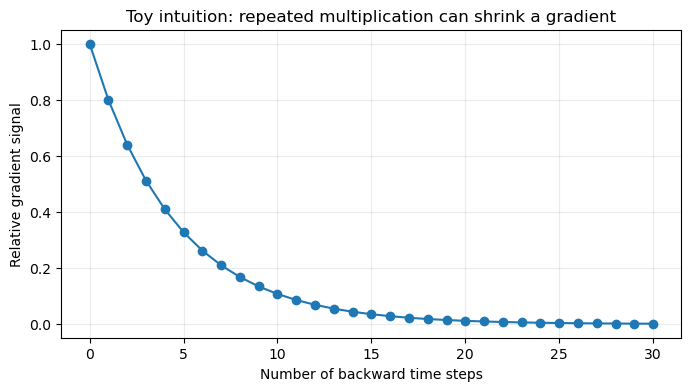

Signal after 5 steps : 0.32768
Signal after 20 steps: 0.011529
Signal after 30 steps: 0.001238


In [4]:
# Toy intuition only — this is NOT an actual neural-network gradient.
decay_factor = 0.80
steps = np.arange(0, 31)
relative_signal = decay_factor ** steps

plt.figure(figsize=(8, 4))
plt.plot(steps, relative_signal, marker="o")
plt.xlabel("Number of backward time steps")
plt.ylabel("Relative gradient signal")
plt.title("Toy intuition: repeated multiplication can shrink a gradient")
plt.grid(alpha=0.25)
plt.show()

print("Signal after 5 steps :", round(float(relative_signal[5]), 6))
print("Signal after 20 steps:", round(float(relative_signal[20]), 6))
print("Signal after 30 steps:", round(float(relative_signal[30]), 6))



<div style="border-left:5px solid #6B5B95; background-color:#F3F1F7; padding:10px 15px; margin:10px 0; border-radius:4px; color:#332D40;">
<b>Do not over-interpret the graph:</b> real neural-network gradients are more complicated than
<code>0.8 ** steps</code>. The plot is only a numerical illustration of why repeated shrinking can destroy
long-range learning signals.
</div>



<a id="section5"></a>
<h2 style="color:#F2C57C; background-color:#6B5B95; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">5. LSTMs &amp; GRUs — Gated Memory</h2>

<h3 style="color:#F2C57C; font-weight:bold; background-color:#3D3456; display:inline-block; padding:4px 10px; border-radius:6px;">5.1 LSTM</h3>

<b>LSTM</b> stands for <b>Long Short-Term Memory</b>. It extends the recurrent idea with a dedicated memory cell and
learned gates that regulate information flow.

<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;"><table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#6B5B95; color:#F2C57C;"><th style="padding:8px; text-align:left;">LSTM Part</th><th style="padding:8px; text-align:left;">Question It Learns to Answer</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Forget gate</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">What old information should be removed?</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Input gate</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">What new information should be stored?</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Cell state</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">What long-term information should continue forward?</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Output gate</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">What part of the memory should influence the current output?</td></tr>
</table></div>

<div style="border-left:5px solid #4AA883; background-color:#DFF3EA; padding:10px 15px; margin:10px 0; border-radius:4px; color:#285943;">
Because information has a more controlled path through the memory cell, LSTMs handle long-range dependencies
much better in practice than a plain RNN.
</div>



<h3 style="color:#F2C57C; font-weight:bold; background-color:#3D3456; display:inline-block; padding:4px 10px; border-radius:6px;">5.2 GRU</h3>

A <b>GRU (Gated Recurrent Unit)</b> is a simpler gated recurrent architecture. It has fewer gates than an LSTM,
so it can be faster while often giving comparable performance.

<div style="border:1px solid #ccc; border-radius:6px; overflow:hidden;"><table style="width:100%; border-collapse:collapse;">
<tr style="background-color:#6B5B95; color:#F2C57C;"><th style="padding:8px; text-align:left;">Model</th><th style="padding:8px; text-align:left;">Memory Style</th><th style="padding:8px; text-align:left;">Typical Characteristic</th></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">SimpleRNN</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Single recurrent hidden state</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Simple but weak on long dependencies</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">LSTM</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Hidden state + cell state + gates</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Strong long-term memory control</td></tr>
<tr style="background-color:#ffffff;"><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">GRU</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Simplified gated state</td><td style="padding:8px; border-top:1px solid #eee; color:#1a1a1a;">Fewer parameters; often efficient</td></tr>
</table></div>



<a id="section6"></a>
<h2 style="color:#F2C57C; background-color:#6B5B95; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">6. Embeddings for Representing Text</h2>

Neural networks cannot directly understand words such as <code>"excellent"</code> or <code>"boring"</code>.
Text is first converted to integer token IDs, then an <b>Embedding</b> layer maps each token ID to a dense learned vector.

<div style="border-left:5px solid #6B5B95; background-color:#F3F1F7; padding:10px 15px; margin:10px 0; border-radius:4px; color:#332D40;">
<span style="display:inline-block; background:#ffffff; border:1px solid #D7C9E8; border-radius:6px; padding:6px 10px; margin:3px 5px 3px 0; color:#3D3456; font-weight:bold;">Token ID → Vector</span>
<span style="display:inline-block; background:#ffffff; border:1px solid #D7C9E8; border-radius:6px; padding:6px 10px; margin:3px 5px 3px 0; color:#3D3456; font-weight:bold;">Learned during training</span>
<span style="display:inline-block; background:#ffffff; border:1px solid #D7C9E8; border-radius:6px; padding:6px 10px; margin:3px 5px 3px 0; color:#3D3456; font-weight:bold;">Compact representation</span><br><br>
For example, with <code>Embedding(10000, 64)</code>, each of the 10,000 vocabulary IDs is represented by a learned
64-dimensional vector.
</div>


In [5]:
# Small embedding-shape demonstration
demo_embedding = keras.Sequential([
    layers.Embedding(input_dim=100, output_dim=8)
])

demo_tokens = tf.constant([[4, 12, 7, 9]])
demo_vectors = demo_embedding(demo_tokens)

print("Token IDs shape       :", demo_tokens.shape)
print("Embedding output shape:", demo_vectors.shape)
print("\nEach token now has an 8-dimensional learned vector.")


Token IDs shape       : (1, 4)
Embedding output shape: (1, 4, 8)

Each token now has an 8-dimensional learned vector.



<a id="section7"></a>
<h2 style="color:#F2C57C; background-color:#6B5B95; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">7. Hands-On Dataset — IMDb Sentiment</h2>

The IMDb dataset contains movie reviews labeled as <b>positive</b> or <b>negative</b>.
Keras provides a preprocessed version in which each review is already represented as a sequence of integer word IDs.

<div style="border-left:5px solid #D76B82; background-color:#FDECEF; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7A3344;">
<b>Why this is a good Day 3 lab:</b> it is a true sequential classification problem. We can deliberately compare
a model that ignores order with RNN/LSTM models that preserve order.
</div>


In [6]:
# Main experiment configuration
VOCAB_SIZE = 10_000
MAX_LEN = 200
EMBED_DIM = 64
BATCH_SIZE = 128
EPOCHS = 6
VAL_SIZE = 5_000

# Set FAST_RUN=True if you only want a quick CPU test.
FAST_RUN = False

print({
    "VOCAB_SIZE": VOCAB_SIZE,
    "MAX_LEN": MAX_LEN,
    "EMBED_DIM": EMBED_DIM,
    "BATCH_SIZE": BATCH_SIZE,
    "EPOCHS": EPOCHS,
    "FAST_RUN": FAST_RUN,
})


{'VOCAB_SIZE': 10000, 'MAX_LEN': 200, 'EMBED_DIM': 64, 'BATCH_SIZE': 128, 'EPOCHS': 6, 'FAST_RUN': False}


<h3 style="color:#F2C57C; font-weight:bold; background-color:#3D3456; display:inline-block; padding:4px 10px; border-radius:6px;">7.1 Dataset Folder Structure</h3>

<div style="border-left:5px solid #6B5B95; background-color:#F3F1F7; padding:10px 15px; margin:10px 0; border-radius:4px; color:#332D40;">
Keep the notebook and dataset folder together, just like Day 2:
</div>

<pre style="background-color:#3D3456; color:#ffffff; padding:14px; border-radius:6px; line-height:1.6;">Day 3/
├── dataset/
│   └── imdb.npz
├── Day3.ipynb
└── README.md</pre>

<div style="border-left:5px solid #4AA883; background-color:#DFF3EA; padding:10px 15px; margin:10px 0; border-radius:4px; color:#285943;">
On the first run only, <code>imdb.npz</code> may not exist yet. The notebook downloads IMDb through Keras and saves
the processed sequences to that exact path. On later runs, it loads the local file directly.
</div>


In [ ]:

from pathlib import Path

DATASET_DIR = Path("dataset")
LOCAL_DATASET = DATASET_DIR / "imdb.npz"

DATASET_DIR.mkdir(parents=True, exist_ok=True)

if LOCAL_DATASET.exists():
    print("Loading local dataset:", LOCAL_DATASET.resolve())

    local_data = np.load(LOCAL_DATASET, allow_pickle=True)

    x_train_raw = local_data["x_train"].tolist()
    y_train_raw = local_data["y_train"].astype(np.int32)

    x_test_raw = local_data["x_test"].tolist()
    y_test_raw = local_data["y_test"].astype(np.int32)

else:
    print("Local dataset not found.")
    print("Downloading IMDb once, then saving it inside dataset/imdb.npz ...")

    (x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = keras.datasets.imdb.load_data(
        num_words=VOCAB_SIZE
    )

    np.savez_compressed(
        LOCAL_DATASET,
        x_train=np.asarray(x_train_raw, dtype=object),
        y_train=np.asarray(y_train_raw, dtype=np.int32),
        x_test=np.asarray(x_test_raw, dtype=object),
        y_test=np.asarray(y_test_raw, dtype=np.int32),
    )

    print("Saved local dataset:", LOCAL_DATASET.resolve())

print("\nRaw training reviews:", len(x_train_raw))
print("Raw test reviews    :", len(x_test_raw))
print("First raw review length:", len(x_train_raw[0]))
print("First label (0=negative, 1=positive):", int(y_train_raw[0]))


Loading local dataset: C:\Users\sadee\OneDrive\Desktop\The Main Folder\The Main Folder\Week 7\Day 3\dataset\imdb.npz

Raw training reviews: 25000
Raw test reviews    : 25000
First raw review length: 218
First label (0=negative, 1=positive): 1


In [8]:
# Reproducible train/validation split
indices = np.arange(len(x_train_raw))
rng = np.random.default_rng(SEED)
rng.shuffle(indices)

val_idx = indices[:VAL_SIZE]
train_idx = indices[VAL_SIZE:]

x_train = [x_train_raw[i] for i in train_idx]
y_train = np.asarray(y_train_raw)[train_idx]

x_val = [x_train_raw[i] for i in val_idx]
y_val = np.asarray(y_train_raw)[val_idx]

x_test = list(x_test_raw)
y_test = np.asarray(y_test_raw)

if FAST_RUN:
    x_train = x_train[:10_000]
    y_train = y_train[:10_000]
    x_val = x_val[:2_500]
    y_val = y_val[:2_500]
    x_test = x_test[:5_000]
    y_test = y_test[:5_000]

# Pad/truncate every review to a fixed length
x_train_pad = keras.utils.pad_sequences(
    x_train, maxlen=MAX_LEN, padding="post", truncating="post"
)
x_val_pad = keras.utils.pad_sequences(
    x_val, maxlen=MAX_LEN, padding="post", truncating="post"
)
x_test_pad = keras.utils.pad_sequences(
    x_test, maxlen=MAX_LEN, padding="post", truncating="post"
)

print("Train shape:", x_train_pad.shape)
print("Val shape  :", x_val_pad.shape)
print("Test shape :", x_test_pad.shape)
print("Train positive rate:", round(float(y_train.mean()), 4))


Train shape: (20000, 200)
Val shape  : (5000, 200)
Test shape : (25000, 200)
Train positive rate: 0.5



<div style="border-left:5px solid #4AA883; background-color:#DFF3EA; padding:10px 15px; margin:10px 0; border-radius:4px; color:#285943;">
<b>Padding:</b> Reviews have different lengths, but a batch tensor needs consistent dimensions.
We use <code>MAX_LEN = 200</code>; shorter reviews receive zeros and longer reviews are truncated.
The embedding layers below use <code>mask_zero=True</code> so recurrent models can ignore padding tokens.
</div>


<div style="border-left:5px solid #E29A3B; background-color:#FFF5E6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7A4C16;">
<b>Text preview note:</b> Decoding integer IDs back to words uses Keras' IMDb word-index metadata.
If that metadata is not already cached, this small vocabulary file may also download once.
The actual training/test sequences remain stored locally in <code>dataset/imdb.npz</code>.
</div>


In [9]:
# Decode a review back into approximate text for inspection
word_index = keras.datasets.imdb.get_word_index()
reverse_word_index = {value + 3: key for key, value in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

def decode_review(token_ids, max_words=80):
    words = [reverse_word_index.get(int(i), "?") for i in token_ids[:max_words]]
    return " ".join(words)

sample_idx = 0
print("Label:", "Positive" if y_train[sample_idx] == 1 else "Negative")
print("\nDecoded review preview:\n")
print(decode_review(x_train[sample_idx]))


Label: Negative

Decoded review preview:

<START> it seems that the intention of the film was to show the aggressive <UNK> like character of russians or at least of those russians able to travel outside their big country that it is too easy to rob a bank in england and that british police is so <UNK> that it cannot find the person who robbed the bank even when these subjects are leaving the country by air in addition nicole kidman and the supposed russian colleagues spoke



<h3 style="color:#F2C57C; font-weight:bold; background-color:#3D3456; display:inline-block; padding:4px 10px; border-radius:6px;">7.2 Training helpers</h3>

To make the experiment fair, every model uses the same split, batch size, maximum sequence length,
loss function, and early-stopping logic.


In [10]:
def compile_binary_model(model):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc"),
        ],
    )
    return model

def make_callbacks():
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True,
        )
    ]

def fit_and_time(model, name):
    print(f"\nTraining: {name}")
    start = time.perf_counter()
    history = model.fit(
        x_train_pad,
        y_train,
        validation_data=(x_val_pad, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=make_callbacks(),
        verbose=1,
    )
    elapsed = time.perf_counter() - start
    return history, elapsed

def best_val_accuracy(history):
    return float(max(history.history["val_accuracy"]))

def plot_metric(history, metric, title):
    plt.figure(figsize=(8, 4))
    plt.plot(history.history[metric], marker="o", label=f"Train {metric}")
    plt.plot(history.history[f"val_{metric}"], marker="o", label=f"Validation {metric}")
    plt.xlabel("Epoch")
    plt.ylabel(metric.replace("_", " ").title())
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()



<a id="section8"></a>
<h2 style="color:#F2C57C; background-color:#6B5B95; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">8. Model A — Non-Sequential Baseline</h2>

This model intentionally removes most order information:

<ol style="line-height:1.8;">
<li>Convert tokens to embeddings.</li>
<li>Average all token vectors across the review.</li>
<li>Classify the averaged representation.</li>
</ol>

<div style="border-left:5px solid #E29A3B; background-color:#FFF5E6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7A4C16;">
<b>Why it is useful:</b> <code>GlobalAveragePooling1D</code> creates a strong simple baseline, but averaging is nearly
order-invariant. If the same words are rearranged, their average embedding stays the same. This gives us a clean
comparison against order-aware recurrent models.
</div>


In [11]:
baseline_model = keras.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True),
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.30),
    layers.Dense(1, activation="sigmoid"),
], name="NonSequential_Baseline")

compile_binary_model(baseline_model)
baseline_model.summary()


Model: "NonSequential_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 644,225 (2.46 MB)

 Trainable params: 644,225 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history_baseline, time_baseline = fit_and_time(
    baseline_model, "Non-Sequential Baseline"
)

print(f"\nBest validation accuracy: {best_val_accuracy(history_baseline):.4f}")
print(f"Training time: {time_baseline:.1f} seconds")



Training: Non-Sequential Baseline
Epoch 1/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7354 - auc: 0.8174 - loss: 0.5764 - val_accuracy: 0.8386 - val_auc: 0.9217 - val_loss: 0.3851
Epoch 2/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8658 - auc: 0.9394 - loss: 0.3257 - val_accuracy: 0.8740 - val_auc: 0.9450 - val_loss: 0.3033
Epoch 3/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9013 - auc: 0.9626 - loss: 0.2521 - val_accuracy: 0.8790 - val_auc: 0.9488 - val_loss: 0.2924
Epoch 4/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9220 - auc: 0.9739 - loss: 0.2091 - val_accuracy: 0.8776 - val_auc: 0.9489 - val_loss: 0.2984
Epoch 5/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9380 - auc: 0.9810 - loss: 0.1763 - val_accuracy: 0.8764 - val_auc: 0.9474 - val_loss: 0.3126

Best validation accuracy: 0.8790
Training time: 6.7 seconds


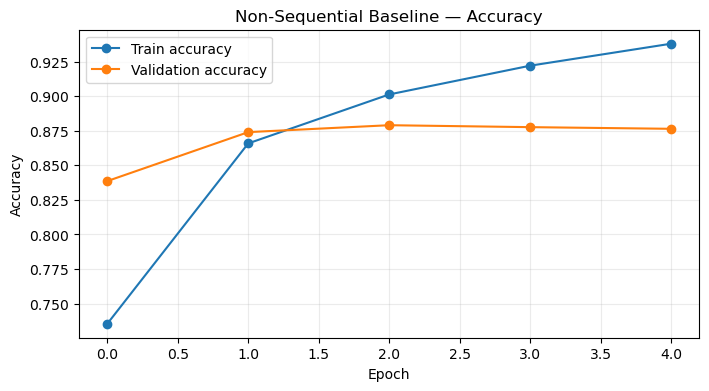

In [13]:
plot_metric(
    history_baseline,
    "accuracy",
    "Non-Sequential Baseline — Accuracy"
)



<a id="section9"></a>
<h2 style="color:#F2C57C; background-color:#6B5B95; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">9. Model B — Simple RNN</h2>

The SimpleRNN reads embeddings one step at a time and updates a hidden state.
Unlike the baseline, it has an explicit mechanism for preserving sequence order.

<div style="border-left:5px solid #6B5B95; background-color:#F3F1F7; padding:10px 15px; margin:10px 0; border-radius:4px; color:#332D40;">
<b>Expectation:</b> The RNN can use order, but it may struggle when important information must survive across many
time steps because of the vanishing-gradient problem.
</div>


In [14]:
rnn_model = keras.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True),
    layers.SimpleRNN(64),
    layers.Dropout(0.30),
    layers.Dense(1, activation="sigmoid"),
], name="SimpleRNN_Model")

compile_binary_model(rnn_model)
rnn_model.summary()


Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,321 (2.47 MB)

 Trainable params: 648,321 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history_rnn, time_rnn = fit_and_time(
    rnn_model, "Simple RNN"
)

print(f"\nBest validation accuracy: {best_val_accuracy(history_rnn):.4f}")
print(f"Training time: {time_rnn:.1f} seconds")



Training: Simple RNN
Epoch 1/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 110ms/step - accuracy: 0.5508 - auc: 0.5756 - loss: 0.6881 - val_accuracy: 0.5626 - val_auc: 0.5947 - val_loss: 0.6791
Epoch 2/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 105ms/step - accuracy: 0.7155 - auc: 0.7839 - loss: 0.5738 - val_accuracy: 0.6510 - val_auc: 0.7314 - val_loss: 0.6273
Epoch 3/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - accuracy: 0.8478 - auc: 0.9229 - loss: 0.3653 - val_accuracy: 0.7272 - val_auc: 0.7958 - val_loss: 0.5757
Epoch 4/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 103ms/step - accuracy: 0.9344 - auc: 0.9823 - loss: 0.1808 - val_accuracy: 0.6676 - val_auc: 0.7276 - val_loss: 0.7762
Epoch 5/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 102ms/step - accuracy: 0.9732 - auc: 0.9962 - loss: 0.0887 - val_accuracy: 0.7558 - val_auc: 0.8151 - val_loss: 0.7420

Best validation accuracy: 0.7558
Training time: 99.3 seconds


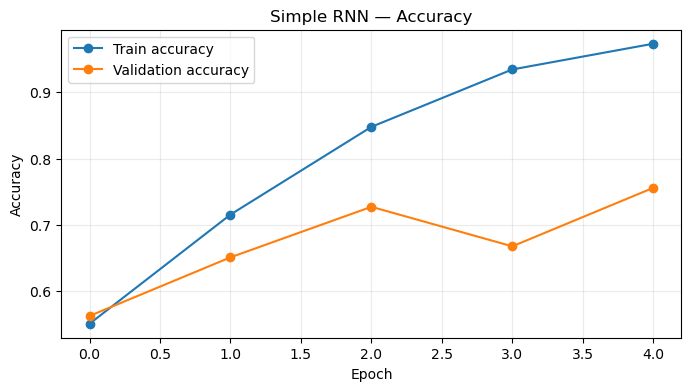

In [16]:
plot_metric(
    history_rnn,
    "accuracy",
    "Simple RNN — Accuracy"
)



<a id="section10"></a>
<h2 style="color:#F2C57C; background-color:#6B5B95; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">10. Model C — LSTM</h2>

The LSTM replaces the simple recurrent update with gated memory.
It is designed to preserve useful information over longer spans while forgetting irrelevant context.


In [17]:
lstm_model = keras.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True),
    layers.LSTM(64),
    layers.Dropout(0.30),
    layers.Dense(1, activation="sigmoid"),
], name="LSTM_Model")

compile_binary_model(lstm_model)
lstm_model.summary()


Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,089 (2.57 MB)

 Trainable params: 673,089 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history_lstm, time_lstm = fit_and_time(
    lstm_model, "LSTM"
)

print(f"\nBest validation accuracy: {best_val_accuracy(history_lstm):.4f}")
print(f"Training time: {time_lstm:.1f} seconds")



Training: LSTM
Epoch 1/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 51s 279ms/step - accuracy: 0.7603 - auc: 0.8502 - loss: 0.4802 - val_accuracy: 0.8584 - val_auc: 0.9322 - val_loss: 0.3522
Epoch 2/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 79s 260ms/step - accuracy: 0.8860 - auc: 0.9433 - loss: 0.2997 - val_accuracy: 0.8428 - val_auc: 0.9221 - val_loss: 0.3645
Epoch 3/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 39s 247ms/step - accuracy: 0.9081 - auc: 0.9601 - loss: 0.2494 - val_accuracy: 0.8360 - val_auc: 0.9166 - val_loss: 0.3867

Best validation accuracy: 0.8584
Training time: 168.9 seconds


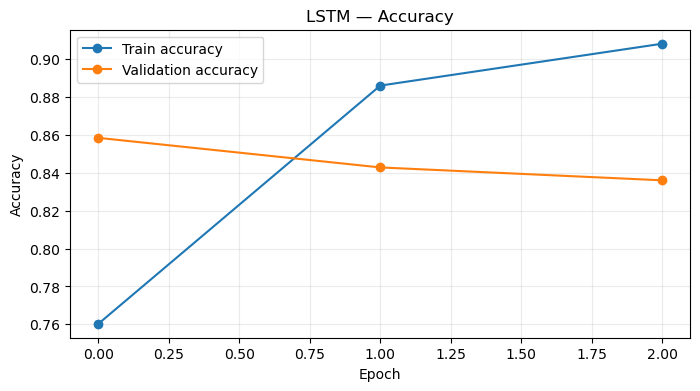

In [19]:
plot_metric(
    history_lstm,
    "accuracy",
    "LSTM — Accuracy"
)



<a id="section11"></a>
<h2 style="color:#F2C57C; background-color:#6B5B95; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">11. Optional GRU Experiment</h2>

GRU is part of the Day 3 key topics. The code below is optional so the required comparison remains focused
on <b>baseline vs plain RNN vs LSTM</b>.

<div style="border-left:5px solid #4AA883; background-color:#DFF3EA; padding:10px 15px; margin:10px 0; border-radius:4px; color:#285943;">
Set <code>RUN_GRU = True</code> if you want to train a fourth model and compare a simpler gated recurrent unit
against the LSTM.
</div>


In [20]:
RUN_GRU = False

gru_model = keras.Sequential([
    layers.Input(shape=(MAX_LEN,)),
    layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True),
    layers.GRU(64),
    layers.Dropout(0.30),
    layers.Dense(1, activation="sigmoid"),
], name="GRU_Model")

compile_binary_model(gru_model)
gru_model.summary()

history_gru = None
time_gru = None

if RUN_GRU:
    history_gru, time_gru = fit_and_time(gru_model, "GRU")
    print(f"\nBest validation accuracy: {best_val_accuracy(history_gru):.4f}")
    print(f"Training time: {time_gru:.1f} seconds")
else:
    print("\nGRU training skipped. Set RUN_GRU=True to run it.")


Model: "GRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 665,025 (2.54 MB)

 Trainable params: 665,025 (2.54 MB)

 Non-trainable params: 0 (0.00 B)


GRU training skipped. Set RUN_GRU=True to run it.



<a id="section12"></a>
<h2 style="color:#F2C57C; background-color:#6B5B95; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">12. Model Comparison &amp; Test Evaluation</h2>

<div style="border-left:5px solid #E29A3B; background-color:#FFF5E6; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7A4C16;">
<b>Evaluation discipline:</b> We choose the best architecture using <b>validation performance</b>.
The test set is kept for final evaluation rather than being used to decide which model to prefer.
</div>


In [21]:
models = {
    "Non-Sequential Baseline": baseline_model,
    "Simple RNN": rnn_model,
    "LSTM": lstm_model,
}

histories = {
    "Non-Sequential Baseline": history_baseline,
    "Simple RNN": history_rnn,
    "LSTM": history_lstm,
}

training_times = {
    "Non-Sequential Baseline": time_baseline,
    "Simple RNN": time_rnn,
    "LSTM": time_lstm,
}

if RUN_GRU and history_gru is not None:
    models["GRU"] = gru_model
    histories["GRU"] = history_gru
    training_times["GRU"] = time_gru

comparison_rows = []

for name, model in models.items():
    test_metrics = model.evaluate(
        x_test_pad, y_test, batch_size=BATCH_SIZE, verbose=0, return_dict=True
    )

    comparison_rows.append({
        "Model": name,
        "Best Val Accuracy": best_val_accuracy(histories[name]),
        "Test Accuracy": float(test_metrics["accuracy"]),
        "Test AUC": float(test_metrics["auc"]),
        "Test Loss": float(test_metrics["loss"]),
        "Training Time (s)": float(training_times[name]),
    })

comparison = pd.DataFrame(comparison_rows)
comparison = comparison.sort_values(
    "Best Val Accuracy", ascending=False
).reset_index(drop=True)

comparison


,Model,Best Val Accuracy,Test Accuracy,Test AUC,Test Loss,Training Time (s)
0,Non-Sequential Baseline,0.8790,0.86172,0.938281,0.321695,6.723913
1,LSTM,0.8584,0.84380,0.923725,0.371863,168.870981
2,Simple RNN,0.7558,0.71920,0.786096,0.589623,99.327182


In [22]:
# Select using validation performance, NOT test accuracy.
best_model_name = comparison.loc[0, "Model"]
best_model = models[best_model_name]

print("Selected model based on validation accuracy:", best_model_name)

test_prob = best_model.predict(x_test_pad, batch_size=BATCH_SIZE, verbose=0).ravel()
test_pred = (test_prob >= 0.5).astype(int)

print("\nClassification report:\n")
print(
    classification_report(
        y_test,
        test_pred,
        target_names=["Negative", "Positive"],
        digits=4,
    )
)


Selected model based on validation accuracy: Non-Sequential Baseline

Classification report:

              precision    recall  f1-score   support

    Negative     0.8467    0.8834    0.8646     12500
    Positive     0.8781    0.8401    0.8587     12500

    accuracy                         0.8617     25000
   macro avg     0.8624    0.8617    0.8617     25000
weighted avg     0.8624    0.8617    0.8617     25000



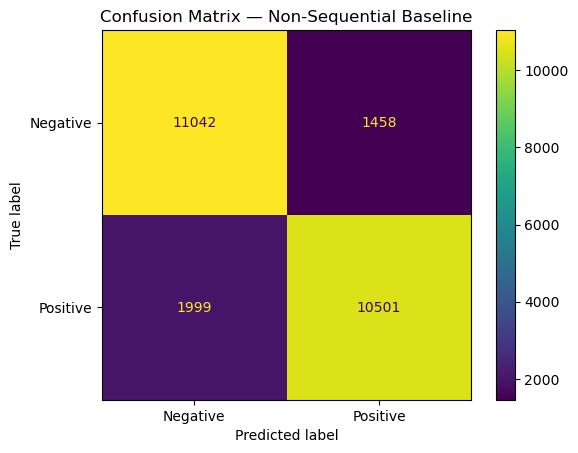

In [23]:
cm = confusion_matrix(y_test, test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"],
)
disp.plot(values_format="d")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()



<div style="border-left:5px solid #D76B82; background-color:#FDECEF; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7A3344;">
<b>Required comparison statement:</b> After running the notebook, write 3–5 sentences below describing:
(1) which model had the best validation result, (2) how the plain RNN compared with the LSTM,
and (3) whether the improvement justified the additional training time.
</div>

**Your result note:**  
_Write your observation here after training._



<a id="section13"></a>
<h2 style="color:#F2C57C; background-color:#6B5B95; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">13. Order-Awareness Experiment</h2>

We now use the <b>same tokens</b> in two orders:

- original review order
- reversed review order

A global-average baseline should be almost unchanged because the token set is unchanged.
A recurrent model can react differently because its hidden state depends on sequence order.


In [24]:
# Choose a reasonably long test review for the order-awareness demonstration
order_sample_idx = next(i for i, seq in enumerate(x_test) if len(seq) >= 80)

original_tokens = x_test[order_sample_idx][:MAX_LEN]
reversed_tokens = list(reversed(original_tokens))

original_pad = keras.utils.pad_sequences(
    [original_tokens], maxlen=MAX_LEN, padding="post", truncating="post"
)
reversed_pad = keras.utils.pad_sequences(
    [reversed_tokens], maxlen=MAX_LEN, padding="post", truncating="post"
)

print("True label:", "Positive" if y_test[order_sample_idx] == 1 else "Negative")
print("\nOriginal text preview:")
print(decode_review(original_tokens, max_words=45))
print("\nReversed token-order preview:")
print(decode_review(reversed_tokens, max_words=45))


True label: Positive

Original text preview:
<START> this film requires a lot of patience because it focuses on mood and character development the plot is very simple and many of the scenes take place on the same set in frances <UNK> the sandy dennis character apartment but the film builds to

Reversed token-order preview:
unconventional with deals that films many his of one is this altman robert praise i br br script written wonderfully the to attention pay and atmosphere the up <UNK> patient be desperation and <UNK> sexual loneliness of study powerful a is movie this short in


In [25]:
def sentiment_probability(model, padded_sequence):
    return float(model.predict(padded_sequence, verbose=0)[0][0])

order_rows = []

for name, model in models.items():
    p_original = sentiment_probability(model, original_pad)
    p_reversed = sentiment_probability(model, reversed_pad)

    order_rows.append({
        "Model": name,
        "P(Positive) Original": p_original,
        "P(Positive) Reversed": p_reversed,
        "Absolute Change": abs(p_original - p_reversed),
    })

order_comparison = pd.DataFrame(order_rows).sort_values(
    "Absolute Change", ascending=False
)
order_comparison


,Model,P(Positive) Original,P(Positive) Reversed,Absolute Change
1,Simple RNN,0.905355,0.853372,0.051983
2,LSTM,0.904667,0.896005,0.008662
0,Non-Sequential Baseline,0.992769,0.992769,0.000000



<div style="border-left:5px solid #6B5B95; background-color:#F3F1F7; padding:10px 15px; margin:10px 0; border-radius:4px; color:#332D40;">
<b>How to interpret the experiment:</b> The non-sequential averaging model is expected to change very little because
it averages the same token embeddings regardless of order. RNN/LSTM predictions may change because they process
the sequence step by step. This is an intuition experiment, not a formal proof that one architecture is universally better.
</div>


<a id="section14"></a>
<h2 style="color:#F2C57C; background-color:#6B5B95; font-weight:bold; margin-top:30px; padding:8px 14px; border-radius:6px;">14. What I Learned Today</h2>

<div style="border-left:5px solid #4AA883; background-color:#DFF3EA; padding:10px 15px; margin:10px 0; border-radius:4px; color:#285943;">
<b>Day 3 Summary:</b> Today I learned how neural networks can process sequential data where the order of information matters.
</div>

### What I learned

- I learned why **sequential data** is different from image or tabular data and why the order of elements can change the meaning.
- I understood how a **Recurrent Neural Network (RNN)** processes a sequence step by step.
- I learned that the **hidden state** works like a memory that carries information from previous time steps.
- I understood the **vanishing-gradient problem** and why a plain RNN may struggle with long sequences.
- I learned how an **LSTM** uses gates to decide what information to keep, forget, and pass forward.
- I learned the basic idea of a **GRU** and how it is a simpler gated recurrent architecture.
- I understood how an **Embedding layer** converts word IDs into learned numerical vectors.
- I trained and compared a **Non-Sequential Baseline**, **SimpleRNN**, and **LSTM** on sentiment data.
- I learned why model selection should be based on **validation performance** while the test set is saved for final evaluation.
- I used an **order-awareness experiment** to see how recurrent models can react when the same tokens are presented in a different order.

<div style="border-left:5px solid #D76B82; background-color:#FDECEF; padding:10px 15px; margin:10px 0; border-radius:4px; color:#7A3344;">
<b>Most important idea:</b> Choosing the correct neural-network architecture depends on the data type.
CNNs are designed for spatial data such as images, while RNNs and LSTMs are designed for ordered sequential data.
</div>


<h3 style="text-align:center; color:#6B5B95; margin-top:28px;">End of Week 7 — Day 3</h3>
